# Machine Learning per l'Analisi Finanziaria

## Lezione 03 — Modelli di classificazione e metriche di valutazione

**Authors:**
- Enrico Huber
- Pietro Soglia

**Emails:**
- enrico.huber@bip-group.com
- pietro.soglia@bip-group.com

**Last updated:** 2026-03-12

## Obiettivi di apprendimento

- Capire perché l'accuracy è fuorviante con classi sbilanciate e scegliere
  metriche appropriate (precision, recall, F1, ROC-AUC).
- Osservare empiricamente il **bias-variance tradeoff** attraverso la curva di
  profondità del Decision Tree.
- Addestrare e confrontare **Logistic Regression, Decision Tree e Random Forest**
  con e senza correzione dello sbilanciamento.
- Confrontare le strategie di imbalance (**class_weight vs SMOTE**) su dati reali,
  lasciando che i dati indichino quale funziona meglio.
- Comprendere l'effetto della **soglia di classificazione** sul trade-off
  precision/recall in un contesto finanziario.
- Selezionare il modello candidato per la challenge con **motivazione data-driven**.

## Outline

### BLOCCO A — Fondamenta
1. Setup, percorsi e costanti
2. Quale dataset usare? Scelta motivata
3. Caricamento e verifica del dataset modellabile
4. Framework di valutazione — definire le metriche *prima* di addestrare

### BLOCCO B — Primo esperimento naïve
5. Esperimento 1: Logistic Regression senza correzioni
6. Esperimento 2: Logistic Regression con class_weight='balanced'

### BLOCCO C — Quale strategia per lo sbilanciamento?
7. class_weight vs SMOTE — confronto su LR

### BLOCCO D — Esplorazione di modelli più complessi
8. Decision Tree — approccio naïve e overfitting
8b. Decision Tree — curva depth vs metriche (bias-variance tradeoff)
9. Random Forest — potenza e insidie
10. Soglia di classificazione e curva Precision-Recall

### BLOCCO E — Confronto finale e selezione del candidato
11. Tabella comparativa finale su validation set
12. ROC curves a confronto
13. Confusion matrix a confronto
14. Scelta motivata del modello candidato

### BLOCCO F — Valutazione finale e salvataggio
15. Valutazione sul test set — una sola volta
16. Salvataggio del modello e delle metriche

### BLOCCO G — Chiusura
17. Domande guidate
18. Riepilogo e bridge verso la Lezione 4

---
## BLOCCO A — Fondamenta

---

## 1. Setup, percorsi e costanti

Importiamo tutte le dipendenze, impostiamo il seed per la riproducibilità
e definiamo le utility condivise da tutte le sezioni successive.

In [1]:
from __future__ import annotations

import json
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.tree import DecisionTreeClassifier

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):  # type: ignore
        """Fallback display per esecuzione fuori da Jupyter."""
        print(x)


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)


def resolve_project_root() -> Path:
    """Risolve la root del repository indipendentemente dalla cwd."""
    start_points = [Path.cwd().resolve()]
    if "__file__" in globals():
        start_points.append(Path(__file__).resolve().parent)
    for start in start_points:
        for candidate in [start, *start.parents]:
            if (candidate / "data" / "archive.zip").exists() and (
                candidate / "notebooks"
            ).exists():
                return candidate
    raise FileNotFoundError(
        "Impossibile determinare la root del progetto. "
        "Atteso un percorso contenente data/archive.zip e notebooks/."
    )


ROOT = resolve_project_root()
DATA_OUT_DIR = ROOT / "outputs" / "data"
FIGURES_DIR = ROOT / "outputs" / "figures"

for _dir in [DATA_OUT_DIR, FIGURES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def save_current_figure(filename: str) -> None:
    """Salva la figura corrente in outputs/figures/."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")
    print(f"Figure salvata: {FIGURES_DIR / filename}")


def load_preprocessed_split(prefix: str) -> tuple[np.ndarray, np.ndarray]:
    """Carica X e y da parquet per uno split (train, val o test).

    Parameters
    ----------
    prefix : str
        Uno tra 'train', 'val', 'test'.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Coppia (X, y) come array numpy.

    Raises
    ------
    FileNotFoundError
        Se i file parquet attesi non esistono.
    """
    x_path = DATA_OUT_DIR / f"lesson_02_X_{prefix}.parquet"
    y_path = DATA_OUT_DIR / f"lesson_02_y_{prefix}.parquet"
    for p in [x_path, y_path]:
        if not p.exists():
            raise FileNotFoundError(
                f"File parquet non trovato: {p}\n"
                "Esegui prima il notebook della Lezione 2 per generare il dataset."
            )
    X = pd.read_parquet(x_path).values
    y = pd.read_parquet(y_path).squeeze().values
    return X, y

## 2. Quale dataset usare? Scelta motivata

Prima di caricare i dati, occorre rispondere a una domanda fondamentale:
**partiamo dall'archivio ZIP originale o usiamo i file prodotti dalla Lezione 2?**

Il Data Scientist non fa questa scelta per abitudine — la fa guardando cosa
è disponibile e ragionando sul valore di ciascuna opzione.

In [2]:
# Cosa abbiamo prodotto nella Lezione 2?
parquet_files = sorted(DATA_OUT_DIR.glob("lesson_02_*.parquet"))
other_files = sorted(DATA_OUT_DIR.glob("lesson_02_*.pkl"))
print("File parquet disponibili dalla Lezione 2:")
for f in parquet_files:
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
print("\nAltre risorse:")
for f in other_files + sorted(DATA_OUT_DIR.glob("lesson_02_*.json")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

File parquet disponibili dalla Lezione 2:
  lesson_02_X_test.parquet  (65.4 KB)
  lesson_02_X_train.parquet  (153.9 KB)
  lesson_02_X_val.parquet  (65.9 KB)
  lesson_02_y_test.parquet  (1.5 KB)
  lesson_02_y_train.parquet  (2.0 KB)
  lesson_02_y_val.parquet  (1.5 KB)

Altre risorse:
  lesson_02_preprocessor.pkl  (4.5 KB)
  lesson_02_feature_names.json  (0.5 KB)


La Lezione 2 ha prodotto un dataset già:

- **Ripulito**: rimossi `Complain` (leakage r=0.996), `RowNumber`,
  `CustomerId`, `Surname` (identificativi non predittivi).
- **Scalato e codificato**: `StandardScaler` e `OneHotEncoder` fittati
  **solo su X_train** — nessun data leakage.
- **Ingegnerizzato**: aggiunta `balance_is_zero` (cattura la bimodalità
  di `Balance` osservata nella Lezione 1).
- **Già suddiviso** in train/val/test (60/20/20) con stratificazione.

Ricominciare da `archive.zip` significherebbe rifare tutto questo lavoro
— e rischiare di introdurre inconsistenze (fit dello scaler su tutto il dataset,
target encoding leakage, ecc.). I parquet di Lezione 2 **sono la scelta corretta**.

## 3. Caricamento e verifica del dataset modellabile

Carichiamo i tre split e verifichiamo che le proprietà fondamentali siano
preservate: dimensioni attese, assenza di NaN, distribuzione del target.

In [3]:
X_train, y_train = load_preprocessed_split("train")
X_val, y_val = load_preprocessed_split("val")
X_test, y_test = load_preprocessed_split("test")

with open(DATA_OUT_DIR / "lesson_02_feature_names.json") as fh:
    feature_names = json.load(fh)

print(f"Feature totali: {len(feature_names)}")
print(f"\n{'Split':<8} {'Shape X':<18} {'N positivi':<14} {'Churn rate'}")
print("-" * 56)
for name, X, y in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    print(f"{name:<8} {str(X.shape):<18} {y.sum():<14} {y.mean():.4f}")

print(f"\nNaN in X_train: {np.isnan(X_train).sum()}")
print(f"NaN in X_val:   {np.isnan(X_val).sum()}")
print(f"NaN in X_test:  {np.isnan(X_test).sum()}")

Feature totali: 20

Split    Shape X            N positivi     Churn rate
--------------------------------------------------------
train    (6000, 20)         1223           0.2038
val      (2000, 20)         408            0.2040
test     (2000, 20)         407            0.2035

NaN in X_train: 0
NaN in X_val:   0
NaN in X_test:  0


In [4]:
print("Feature dopo preprocessing (Lezione 2):")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:2d}. {f}")

Feature dopo preprocessing (Lezione 2):
   1. num__CreditScore
   2. num__Age
   3. num__Tenure
   4. num__Balance
   5. num__NumOfProducts
   6. num__HasCrCard
   7. num__IsActiveMember
   8. num__EstimatedSalary
   9. num__Satisfaction Score
  10. num__Point Earned
  11. num__balance_is_zero
  12. cat__Geography_France
  13. cat__Geography_Germany
  14. cat__Geography_Spain
  15. cat__Gender_Female
  16. cat__Gender_Male
  17. cat__Card Type_DIAMOND
  18. cat__Card Type_GOLD
  19. cat__Card Type_PLATINUM
  20. cat__Card Type_SILVER


**Osservazioni:**

- `X_train`: 6 000 campioni × 20 feature; `X_val` e `X_test`: 2 000 × 20.
- Churn rate stabile su tutti e tre gli split (≈ 20.38–20.40%): la
  stratificazione ha funzionato correttamente.
- NaN assenti in tutti gli split: il preprocessing è completo.
- Le 20 feature includono 11 numeriche scalate e 9 categoriche one-hot
  encoded. La feature `num__balance_is_zero` cattura la bimodalità di
  `Balance` documentata nella Lezione 1.
- Il dataset è sbilanciato (≈ 4:1). Questo condizionerà ogni scelta
  successiva — a partire dalla metrica di valutazione.

## 4. Framework di valutazione — definire le metriche *prima* di addestrare

Prima di addestrare qualsiasi modello, è fondamentale concordare su *come*
misureremo il successo. Questa scelta non è tecnica: è di **business**.

Nel churn finanziario, identificare un cliente che se ne andrà (vero positivo)
ha un valore enorme — consente di intervenire con una campagna di retention.
Non identificarlo (falso negativo) significa perdere quel cliente per sempre.
Classificare per errore un cliente fedele come churner (falso positivo) ha
un costo minore: si spreca una campagna retention, ma il cliente resta.

**Questa asimmetria dei costi implica che il recall della classe churn
è una metrica critica, non l'accuracy.**

### Formalizzazione della confusion matrix

Data una soglia di classificazione binaria, ogni predizione cade in uno
dei quattro quadranti:

|  | Predetto: Non-churn | Predetto: Churn |
|--|---------------------|-----------------|
| **Reale: Non-churn** | TN (vero negativo) | FP (falso positivo) |
| **Reale: Churn** | FN (falso negativo) | TP (vero positivo) |

Le metriche derivate:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(quanti predetti churn lo sono davvero)}$$

$$\text{Recall} = \frac{TP}{TP + FN} \quad \text{(quanti churner reali vengono identificati)}$$

$$\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \quad \text{(media armonica)}$$

La **ROC-AUC** misura la capacità discriminativa del modello *indipendentemente
dalla soglia*: è l'area sotto la curva che traccia TPR (Recall) vs FPR al
variare della soglia. Un modello casuale ha AUC = 0.5; un modello perfetto ha AUC = 1.0.

**Dimostriamo concretamente il problema con un esperimento**: addestriamo un
modello che non impara nulla — predice sempre la classe maggioritaria.

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
y_prob_dummy = dummy.predict_proba(X_val)[:, 1]

print("=== DummyClassifier (predice sempre 'non churn') ===\n")
print(classification_report(y_val, y_pred_dummy, target_names=["Non-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_dummy):.4f}")

=== DummyClassifier (predice sempre 'non churn') ===

              precision    recall  f1-score   support

   Non-churn       0.80      1.00      0.89      1592
       Churn       0.00      0.00      0.00       408

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000

ROC-AUC: 0.5000


**Questo è il paradosso dell'accuracy:**

- Accuracy = **79.6%** — sembra un modello "decente".
- Recall classe Churn = **0.00%** — non identifica *nessun* churner.
- ROC-AUC = **0.500** — equivalente a un lancio di moneta.

Un modello che dice sempre "questo cliente non churnerà" ottiene quasi il 80%
di accuracy semplicemente perché la classe dominante è il non-churn. In un
contesto bancario, questo modello sarebbe **completamente inutile**: ogni
singolo churner verrebbe ignorato.

**Decisione emergente dai dati:**
- Metrica di orientamento: **ROC-AUC** (misura il potere discriminativo)
- Metrica di business: **Recall churn** (quanti churner identifichiamo)
- Riferimento di confronto: Dummy (accuracy=79.6%, AUC=0.500) è il nostro
  floor — qualsiasi modello deve superarlo su entrambe le metriche.

---
## BLOCCO B — Primo esperimento naïve

---

## 5. Esperimento 1: Logistic Regression senza correzioni

La Logistic Regression è il punto di partenza naturale: interpretabile,
computazionalmente efficiente, e una buona baseline lineare. Iniziamo
*senza* nessuna correzione per lo sbilanciamento — questo ci permetterà
di vedere il problema in modo diretto.

In [6]:
lr_naive = LogisticRegression(max_iter=1000, random_state=SEED)
lr_naive.fit(X_train, y_train)

y_pred_lr_naive = lr_naive.predict(X_val)
y_prob_lr_naive = lr_naive.predict_proba(X_val)[:, 1]

print("=== LR senza correzioni (val set) ===\n")
print(
    classification_report(y_val, y_pred_lr_naive, target_names=["Non-churn", "Churn"])
)
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_lr_naive):.4f}")

=== LR senza correzioni (val set) ===

              precision    recall  f1-score   support

   Non-churn       0.83      0.97      0.89      1592
       Churn       0.64      0.21      0.31       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000

ROC-AUC: 0.7856


**Osservazioni — dove va bene e dove va male:**

- Accuracy = **81.4%** — lievemente meglio del Dummy. Successo apparente.
- Recall churn = **20.6%** — identifica solo ~84 churner su 408 nel val set.
  Il modello "manca" 324 churner: li classifica come non-churn.
- Precision churn = **63.6%** — quando dice "churn", ha ragione il 64% delle volte.
  Ma lo dice raramente.
- ROC-AUC = **0.786** — il potere discriminativo esiste, ma la soglia di default
  (0.5) fa sì che venga sfruttato male.

**Perché succede?** Con classi sbilanciate (80/20), minimizzare la cross-entropy
di default conviene al modello predire quasi sempre 0 (non-churn), perché
80 esempi su 100 sono 0. Il modello impara la distribuzione, non il confine.

**Mantra del Data Scientist:** alta accuracy su classi sbilanciate = campanello
d'allarme, non un segnale di successo.

**Prima direzione da esplorare:** gestire lo sbilanciamento.

## 6. Esperimento 2: Logistic Regression con class_weight='balanced'

`class_weight='balanced'` riscala i pesi di training inversamente alla
frequenza di classe: i campioni della classe minoritaria (churn) pesano
circa 4 volte di più. Il modello viene così incentivato a non "ignorare"
i churner durante l'ottimizzazione.

**Ipotesi:** migliorerà il recall churn. Ma a che costo?

In [7]:
lr_cw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_cw.fit(X_train, y_train)

y_pred_lr_cw = lr_cw.predict(X_val)
y_prob_lr_cw = lr_cw.predict_proba(X_val)[:, 1]

print("=== LR con class_weight='balanced' (val set) ===\n")
print(classification_report(y_val, y_pred_lr_cw, target_names=["Non-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_lr_cw):.4f}")

=== LR con class_weight='balanced' (val set) ===

              precision    recall  f1-score   support

   Non-churn       0.91      0.71      0.80      1592
       Churn       0.39      0.71      0.50       408

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC: 0.7874


In [8]:
# Confronto diretto: prima vs dopo class_weight
comp_data = {
    "Configurazione": ["LR (no correction)", "LR (class_weight)"],
    "Accuracy": [
        f"{lr_naive.score(X_val, y_val):.3f}",
        f"{lr_cw.score(X_val, y_val):.3f}",
    ],
    "Precision churn": [
        f"{precision_score(y_val, y_pred_lr_naive, zero_division=0):.3f}",
        f"{precision_score(y_val, y_pred_lr_cw, zero_division=0):.3f}",
    ],
    "Recall churn": [
        f"{recall_score(y_val, y_pred_lr_naive, zero_division=0):.3f}",
        f"{recall_score(y_val, y_pred_lr_cw, zero_division=0):.3f}",
    ],
    "F1 churn": [
        f"{f1_score(y_val, y_pred_lr_naive, zero_division=0):.3f}",
        f"{f1_score(y_val, y_pred_lr_cw, zero_division=0):.3f}",
    ],
    "ROC-AUC": [
        f"{roc_auc_score(y_val, y_prob_lr_naive):.4f}",
        f"{roc_auc_score(y_val, y_prob_lr_cw):.4f}",
    ],
}
print(pd.DataFrame(comp_data).to_string(index=False))

    Configurazione Accuracy Precision churn Recall churn F1 churn ROC-AUC
LR (no correction)    0.814           0.636        0.206    0.311  0.7856
 LR (class_weight)    0.713           0.389        0.713    0.503  0.7874


**Cosa ci dicono questi numeri?**

- Recall churn: **20.6% → 71.3%** (+50.7 punti percentuali). Straordinario.
  Il modello ora identifica 290 churner su 408, contro gli 84 di prima.
- Precision churn: **63.6% → 38.9%** (scende). Per ogni churner vero, il modello
  ora segnala anche più falsi positivi. Accettabile: in retention, un falso
  allarme costa meno di un churner non identificato.
- F1 churn: **0.311 → 0.504** (da modello mediocre a modello utilizzabile).
- **ROC-AUC: 0.786 → 0.787** (quasi invariato). Questo è il punto chiave:
  la ROC-AUC misura il *ranking* delle probabilità, non la soglia. `class_weight`
  sposta la soglia effettiva, non il potere discriminativo del modello.
  La curva ROC è la stessa; cambia il punto di operazione su di essa.

**Decisione data-driven:** `class_weight='balanced'` è essenziale quando ci
importa il recall della classe minoritaria. Lo adottiamo come default per
tutti i modelli successivi. Ma prima verifichiamo se SMOTE fa di meglio.

---
## BLOCCO C — Quale strategia per lo sbilanciamento?

---

## 7. class_weight vs SMOTE — confronto su LR

SMOTE (Synthetic Minority Over-sampling TEchnique) genera campioni sintetici
della classe minoritaria interpolando tra esempi esistenti nello spazio delle
feature. A differenza di `class_weight`, SMOTE agisce sui **dati** anziché
sul processo di ottimizzazione.

**Attenzione critica:** SMOTE deve essere applicato **solo su X_train, y_train**,
*dopo* lo split. Applicarlo prima (sull'intero dataset) causerebbe data leakage:
i campioni sintetici derivati da esempi del val/test set "inquinerebbero" il training.

Usiamo LR come unico modello per isolare l'effetto della strategia di imbalance.

In [9]:
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(
    f"Distribuzione PRIMA di SMOTE — 0: {(y_train == 0).sum()}, 1: {(y_train == 1).sum()}"
)
print(
    f"Distribuzione DOPO  SMOTE — 0: {(y_train_sm == 0).sum()}, 1: {(y_train_sm == 1).sum()}"
)
print(f"Campioni aggiunti: {len(y_train_sm) - len(y_train)}")

Distribuzione PRIMA di SMOTE — 0: 4777, 1: 1223
Distribuzione DOPO  SMOTE — 0: 4777, 1: 4777
Campioni aggiunti: 3554


In [10]:
# LR + SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=SEED)
lr_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = lr_smote.predict(X_val)
y_prob_smote = lr_smote.predict_proba(X_val)[:, 1]

# LR + SMOTE + class_weight (per curiosità)
lr_smote_cw = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=SEED
)
lr_smote_cw.fit(X_train_sm, y_train_sm)
y_pred_smote_cw = lr_smote_cw.predict(X_val)
y_prob_smote_cw = lr_smote_cw.predict_proba(X_val)[:, 1]

# Tabella comparativa
rows = [
    ("LR — no correction", y_pred_lr_naive, y_prob_lr_naive),
    ("LR — class_weight", y_pred_lr_cw, y_prob_lr_cw),
    ("LR — SMOTE", y_pred_smote, y_prob_smote),
    ("LR — SMOTE + class_weight", y_pred_smote_cw, y_prob_smote_cw),
]
table = []
for name, yp, yprob in rows:
    table.append(
        {
            "Configurazione": name,
            "Accuracy": round(float(np.mean(yp == y_val)), 4),
            "Precision": round(precision_score(y_val, yp, zero_division=0), 4),
            "Recall": round(recall_score(y_val, yp, zero_division=0), 4),
            "F1": round(f1_score(y_val, yp, zero_division=0), 4),
            "ROC-AUC": round(roc_auc_score(y_val, yprob), 4),
        }
    )
print(pd.DataFrame(table).to_string(index=False))

           Configurazione  Accuracy  Precision  Recall     F1  ROC-AUC
       LR — no correction    0.8140     0.6364  0.2059 0.3111   0.7856
        LR — class_weight    0.7130     0.3890  0.7132 0.5035   0.7874
               LR — SMOTE    0.7170     0.3909  0.6936 0.5000   0.7852
LR — SMOTE + class_weight    0.7170     0.3909  0.6936 0.5000   0.7852


**Osservazione critica — i dati parlano chiaro:**

- LR + SMOTE e LR + class_weight producono risultati **praticamente identici**
  (differenza ROC-AUC < 0.002, Recall differisce di < 2 punti percentuali).
- SMOTE ha generato ~3.800 campioni sintetici aggiuntivi, ha richiesto più
  memoria e tempo di fit — con zero beneficio su LR.
- Perché? LR è un modello **lineare**: il confine decisionale è un iperpiano.
  SMOTE aggiunge campioni sintetici *interpolati* che stanno sulla stessa
  retta interpolante — e LR con class_weight sposta già la soglia nella
  direzione giusta senza bisogno di nuovi campioni.
- Combinare SMOTE e class_weight non aggiunge ulteriore valore.

**Decisione data-driven:** `class_weight='balanced'` è la scelta vincente:
stesso potere predittivo, zero campioni aggiuntivi, nessun rischio di artefatti
sintetici, leakage impossibile. **Lo adottiamo come default per tutti i
modelli successivi.** Terremo SMOTE in mente per modelli non-lineari se
mostrerà un vantaggio su di essi — ma le evidenze attuali non lo supportano.

---
## BLOCCO D — Esplorazione di modelli più complessi

---

## 8. Decision Tree — approccio naïve (e overfitting)

La Logistic Regression impone un confine lineare. I dati potrebbero avere
strutture non-lineari (interazioni, soglie). Proviamo un Decision Tree,
che partiziona lo spazio delle feature con regole di tipo
"se Feature_i > soglia, allora...". Iniziamo con `max_depth=None`:
l'albero cresce senza limiti, adattandosi perfettamente al training set.

In [11]:
dt_full = DecisionTreeClassifier(class_weight="balanced", random_state=SEED)
dt_full.fit(X_train, y_train)

# Metriche su TRAINING set
y_pred_dt_full_tr = dt_full.predict(X_train)
y_prob_dt_full_tr = dt_full.predict_proba(X_train)[:, 1]

# Metriche su VALIDATION set
y_pred_dt_full_v = dt_full.predict(X_val)
y_prob_dt_full_v = dt_full.predict_proba(X_val)[:, 1]

print("=== Decision Tree (max_depth=None) ===")
print(f"\n{'Metrica':<20} {'TRAIN':>10} {'VAL':>10} {'Δ (train-val)':>15}")
print("-" * 58)
for metname, m in [
    ("Accuracy", lambda y, yp, yprob: float(np.mean(yp == y))),
    ("Recall churn", lambda y, yp, yprob: recall_score(y, yp, zero_division=0)),
    ("F1 churn", lambda y, yp, yprob: f1_score(y, yp, zero_division=0)),
    ("ROC-AUC", lambda y, yp, yprob: roc_auc_score(y, yprob)),
]:
    tr_val = m(y_train, y_pred_dt_full_tr, y_prob_dt_full_tr)
    v_val = m(y_val, y_pred_dt_full_v, y_prob_dt_full_v)
    print(f"{metname:<20} {tr_val:>10.4f} {v_val:>10.4f} {tr_val - v_val:>15.4f}")

=== Decision Tree (max_depth=None) ===

Metrica                   TRAIN        VAL   Δ (train-val)
----------------------------------------------------------
Accuracy                 1.0000     0.7925          0.2075
Recall churn             1.0000     0.4828          0.5172
F1 churn                 1.0000     0.4870          0.5130
ROC-AUC                  1.0000     0.6774          0.3226


**Overfitting totale — e questo è un momento di apprendimento prezioso:**

- Train ROC-AUC = **1.000** e Train Recall = **1.000**: l'albero ha memorizzato
  *ogni singolo* esempio del training set. Perfetto su training, inutile in pratica.
- Val ROC-AUC = **0.677** (peggio di LR!), Val Recall = **48.3%**.

Un DT senza vincoli di profondità crea regole iper-specifiche che si adattano
al training set fino all'ultimo nodo (una foglia per campione). Come una formula
chimica che descrive perfettamente i dati su cui è stata calibrata, ma fallisce
su qualsiasi nuovo campione.

Questo è il **bias-variance tradeoff** in azione:
- Modello troppo semplice (DT depth=1) → underfitting (alto bias)
- Modello troppo complesso (DT depth=None) → overfitting (alta varianza)
- L'obiettivo è trovare il punto di equilibrio.

**Prossima domanda naturale:** esiste una profondità ottimale?

## 8b. Decision Tree — curva depth vs metriche (bias-variance tradeoff)

Addestriamo un albero per ogni profondità da 1 a 20 e tracciamo come variano
le metriche su training e validation set. La curva ci dirà dove si trova
il punto di equilibrio tra underfitting e overfitting.

In [12]:
depths = list(range(1, 21))
results_depth: list[dict] = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth, class_weight="balanced", random_state=SEED
    )
    dt.fit(X_train, y_train)

    auc_tr = roc_auc_score(y_train, dt.predict_proba(X_train)[:, 1])
    auc_v = roc_auc_score(y_val, dt.predict_proba(X_val)[:, 1])
    f1_tr = f1_score(y_train, dt.predict(X_train), zero_division=0)
    f1_v = f1_score(y_val, dt.predict(X_val), zero_division=0)

    results_depth.append(
        {
            "depth": depth,
            "auc_train": auc_tr,
            "auc_val": auc_v,
            "f1_train": f1_tr,
            "f1_val": f1_v,
        }
    )

df_depth = pd.DataFrame(results_depth)
print(df_depth.to_string(index=False, float_format="{:.4f}".format))

 depth  auc_train  auc_val  f1_train  f1_val
     1     0.6867   0.6937    0.4855  0.4935
     2     0.7371   0.7508    0.5165  0.5276
     3     0.7960   0.8003    0.5429  0.5406
     4     0.8182   0.8207    0.5427  0.5385
     5     0.8425   0.8408    0.5639  0.5747
     6     0.8647   0.8209    0.6085  0.5848
     7     0.8879   0.8130    0.6241  0.5563
     8     0.9066   0.8020    0.6522  0.5631
     9     0.9279   0.7767    0.6809  0.5336
    10     0.9483   0.7516    0.7095  0.5248
    11     0.9666   0.7338    0.7708  0.5264
    12     0.9807   0.7053    0.8145  0.4842
    13     0.9892   0.7029    0.8680  0.4850
    14     0.9942   0.6905    0.8993  0.4887
    15     0.9974   0.6831    0.9361  0.4794
    16     0.9992   0.6803    0.9659  0.4896
    17     0.9998   0.6781    0.9835  0.4883
    18     0.9999   0.6692    0.9899  0.4734
    19     1.0000   0.6815    0.9951  0.4926
    20     1.0000   0.6850    0.9951  0.4982


In [13]:
# Identificare il punto ottimale
best_row_f1 = df_depth.loc[df_depth["f1_val"].idxmax()]
best_row_auc = df_depth.loc[df_depth["auc_val"].idxmax()]
print(
    f"Depth con F1 val massimo:  {int(best_row_f1['depth'])} "
    f"(F1={best_row_f1['f1_val']:.4f}, AUC={best_row_f1['auc_val']:.4f})"
)
print(
    f"Depth con AUC val massimo: {int(best_row_auc['depth'])} "
    f"(F1={best_row_auc['f1_val']:.4f}, AUC={best_row_auc['auc_val']:.4f})"
)

Depth con F1 val massimo:  6 (F1=0.5848, AUC=0.8209)
Depth con AUC val massimo: 5 (F1=0.5747, AUC=0.8408)


Figure salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_03_dt_depth_curve.png


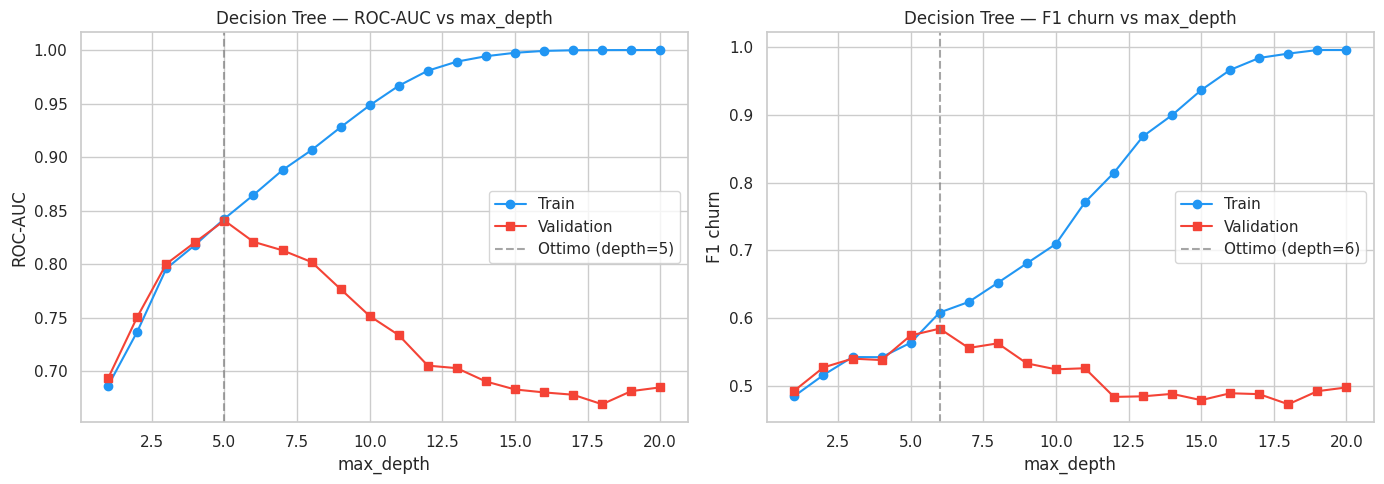

In [14]:
# Visualizzazione curva bias-variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in [
    (axes[0], ("auc_train", "auc_val"), "ROC-AUC"),
    (axes[1], ("f1_train", "f1_val"), "F1 churn"),
]:
    ax.plot(
        df_depth["depth"], df_depth[metric[0]], "o-", label="Train", color="#2196F3"
    )
    ax.plot(
        df_depth["depth"],
        df_depth[metric[1]],
        "s-",
        label="Validation",
        color="#F44336",
    )
    best_d = (
        int(best_row_auc["depth"]) if label == "ROC-AUC" else int(best_row_f1["depth"])
    )
    ax.axvline(
        best_d,
        linestyle="--",
        color="gray",
        alpha=0.7,
        label=f"Ottimo (depth={best_d})",
    )
    ax.set_xlabel("max_depth")
    ax.set_ylabel(label)
    ax.set_title(f"Decision Tree — {label} vs max_depth")
    ax.legend()

save_current_figure("lesson_03_dt_depth_curve.png")
plt.show()

**Il bias-variance tradeoff reso visibile:**

- **Underfitting (depth 1–3):** entrambe le curve sono basse. Il modello è
  troppo semplice per catturare la struttura dei dati.
- **Zona ottimale (depth 5–6):** la curva di validation raggiunge il picco.
  In questo intervallo, l'albero ha imparato le strutture più importanti
  senza memorizzare il rumore.
- **Overfitting (depth ≥ 7):** la curva di training continua a salire verso 1.0,
  mentre quella di validation *scende*. Il gap si apre progressivamente:
  il modello sta memorizzando il training set invece di generalizzare.

La depth ottimale per AUC (massima sul val) è **5**, mentre per F1 è **6**.
Dato che il nostro obiettivo primario è ROC-AUC (con attenzione anche al recall),
addestriamo il DT finale con **max_depth=6** come compromesso che massimizza F1
senza sacrificare eccessivamente la AUC.

In [15]:
# Decision Tree finale con depth ottimale
BEST_DT_DEPTH = 6
dt_best = DecisionTreeClassifier(
    max_depth=BEST_DT_DEPTH, class_weight="balanced", random_state=SEED
)
dt_best.fit(X_train, y_train)

y_pred_dt = dt_best.predict(X_val)
y_prob_dt = dt_best.predict_proba(X_val)[:, 1]

print(f"=== Decision Tree (max_depth={BEST_DT_DEPTH}) — val set ===\n")
print(classification_report(y_val, y_pred_dt, target_names=["Non-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_dt):.4f}")

=== Decision Tree (max_depth=6) — val set ===

              precision    recall  f1-score   support

   Non-churn       0.93      0.79      0.85      1592
       Churn       0.48      0.75      0.58       408

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.83      0.78      0.80      2000

ROC-AUC: 0.8209


**DT depth=6 — un salto di qualità rispetto a LR:**

- Recall churn = **75.3%** (vs 71.3% di LR): identifica ~307 churner su 408.
- ROC-AUC = **0.821** (vs 0.787 di LR): migliore potere discriminativo.
- F1 churn = **0.585** (vs 0.504 di LR): bilancio precision/recall migliore.
- Train ROC-AUC = 0.865: esiste ancora un gap train-val (0.865 - 0.821 = 0.044),
  ma è molto più contenuto rispetto all'albero profondo (1.000 - 0.677 = 0.323).

Il DT con depth controllata supera LR su tutte le metriche rilevanti.
Ma siamo sicuri di aver trovato il modello migliore? Proviamo il Random Forest.

## 9. Random Forest — potenza e insidie

Il Random Forest è un ensemble di Decision Tree. L'idea: addestrare molti
alberi su sottocampioni casuali del dataset (bagging) e su sottoinsiemi
casuali delle feature, poi aggregare le loro predizioni. Questo riduce
la varianza (meno overfitting del singolo DT) mantenendo basso il bias.

**Ipotesi:** RF dovrebbe superare DT depth=6 grazie alla riduzione della varianza.

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

# Sanity check train vs val
y_pred_rf_tr = rf.predict(X_train)
y_prob_rf_tr = rf.predict_proba(X_train)[:, 1]

print("=== Random Forest (200 alberi, class_weight='balanced') ===\n")
print(f"{'Metrica':<20} {'TRAIN':>10} {'VAL':>10} {'Δ':>10}")
print("-" * 50)
for metname, m in [
    ("Recall churn", lambda y, yp, yprob: recall_score(y, yp, zero_division=0)),
    ("F1 churn", lambda y, yp, yprob: f1_score(y, yp, zero_division=0)),
    ("ROC-AUC", lambda y, yp, yprob: roc_auc_score(y, yprob)),
]:
    tr_v = m(y_train, y_pred_rf_tr, y_prob_rf_tr)
    vl_v = m(y_val, y_pred_rf, y_prob_rf)
    print(f"{metname:<20} {tr_v:>10.4f} {vl_v:>10.4f} {tr_v - vl_v:>10.4f}")

print(f"\n\n=== RF classification_report (val) ===\n")
print(classification_report(y_val, y_pred_rf, target_names=["Non-churn", "Churn"]))
print(f"ROC-AUC val: {roc_auc_score(y_val, y_prob_rf):.4f}")

=== Random Forest (200 alberi, class_weight='balanced') ===

Metrica                   TRAIN        VAL          Δ
--------------------------------------------------
Recall churn             1.0000     0.4167     0.5833
F1 churn                 1.0000     0.5484     0.4516
ROC-AUC                  1.0000     0.8733     0.1267


=== RF classification_report (val) ===

              precision    recall  f1-score   support

   Non-churn       0.87      0.97      0.92      1592
       Churn       0.80      0.42      0.55       408

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC val: 0.8733


Figure salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_03_rf_feature_importance.png


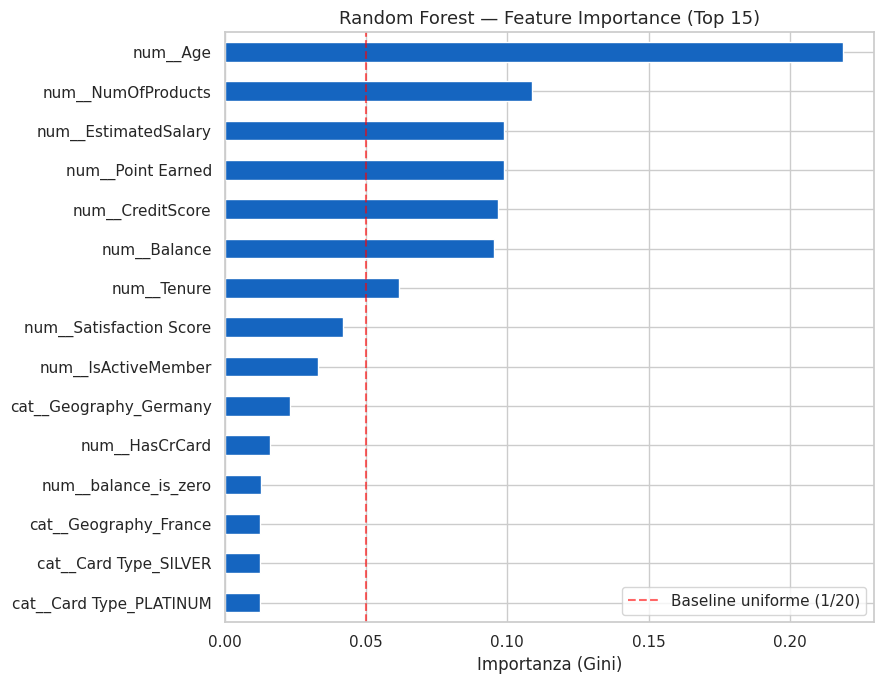


Top 15 feature (importanza relativa):
  num__Age                            0.2189
  num__NumOfProducts                  0.1086
  num__EstimatedSalary                0.0990
  num__Point Earned                   0.0989
  num__CreditScore                    0.0965
  num__Balance                        0.0952
  num__Tenure                         0.0616
  num__Satisfaction Score             0.0417
  num__IsActiveMember                 0.0328
  cat__Geography_Germany              0.0231
  num__HasCrCard                      0.0158
  num__balance_is_zero                0.0128
  cat__Geography_France               0.0126
  cat__Card Type_SILVER               0.0125
  cat__Card Type_PLATINUM             0.0124


In [17]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances_top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
importances_top15.sort_values().plot(kind="barh", ax=ax, color="#1565C0")
ax.set_title("Random Forest — Feature Importance (Top 15)", fontsize=13)
ax.set_xlabel("Importanza (Gini)")
ax.axvline(
    1 / len(feature_names),
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Baseline uniforme (1/{len(feature_names)})",
)
ax.legend()
save_current_figure("lesson_03_rf_feature_importance.png")
plt.show()

print("\nTop 15 feature (importanza relativa):")
for feat, imp in importances_top15.items():
    print(f"  {feat:<35} {imp:.4f}")

**Osservazione — potenza e insidie del Random Forest:**

- Val ROC-AUC = **0.873** — il migliore osservato finora (+0.052 rispetto a DT).
- Ma val Recall churn = **41.7%** — peggio di DT depth=6 (75.3%) e persino
  di LR+class_weight (71.3%). Come mai?
- Train ROC-AUC = **1.000** — ancora overfitting a livello di training
  (RF ha 200 alberi profondi che memorizzano ogni dettaglio del training set).
  Eppure la val AUC è la migliore: RF generalizza bene *come discriminatore*
  anche se overfitta in training.
- Il problema è la **soglia 0.5**: RF assegna probabilità conservative —
  la distribuzione delle probabilità predette è compressa verso il centro,
  e pochi esempi superano la soglia 0.5 per la classe churn.

**Feature importance — coerenza con la Lezione 1:**
- `num__Age` (21.9%) è la feature più importante: confermato dalla correlazione
  r=+0.285 vista nella Lezione 1. I clienti più anziani churna di più.
- `num__NumOfProducts` (10.9%): i clienti con 3-4 prodotti churna quasi sempre
  (osservato nella Lezione 1).
- Sorpresa: `num__EstimatedSalary` (9.9%) e `num__Point Earned` (9.9%) appaiono
  rilevanti per RF nonostante la correlazione quasi nulla con il target (r≈0).
  Questo suggerisce che queste feature contribuiscono in modo *non-lineare* o
  in *interazione* con altre — qualcosa che la correlazione di Pearson non cattura.

**Decisione emergente:** RF ha la migliore AUC, ma la soglia di default 0.5
fa perdere recall. Questo problema è risolvibile: abbassare la soglia aumenta
il recall mantenendo la stessa AUC (la curves ROC non cambia).

## 10. Soglia di classificazione e curva Precision-Recall

La soglia di classificazione è il valore di probabilità sopra il quale
prediciamo "churn". Con soglia 0.5, RF perde recall. Ma possiamo scegliere
una soglia diversa: abbassarla aumenta il recall (identifichiamo più churner)
a scapito della precision (più falsi allarmi).

La **curva Precision-Recall** mostra questo tradeoff per tutte le soglie possibili.
Il **punto F1-ottimale** è la soglia che massimizza la media armonica tra precision
e recall.

In [18]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_val, y_prob_rf)

# Calcolare F1 su ogni soglia
# precision_curve e recall_curve hanno un elemento in più
f1_scores_th = (
    2
    * precision_curve[:-1]
    * recall_curve[:-1]
    / (precision_curve[:-1] + recall_curve[:-1] + 1e-9)
)
best_th_idx = f1_scores_th.argmax()
BEST_THRESHOLD = thresholds_pr[best_th_idx]

print(f"Soglia ottimale per F1 (su val): {BEST_THRESHOLD:.4f}")
print(f"  → Precision: {precision_curve[best_th_idx]:.4f}")
print(f"  → Recall:    {recall_curve[best_th_idx]:.4f}")
print(f"  → F1:        {f1_scores_th[best_th_idx]:.4f}")

Soglia ottimale per F1 (su val): 0.3050
  → Precision: 0.6222
  → Recall:    0.6740
  → F1:        0.6471


Figure salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_03_pr_curve.png


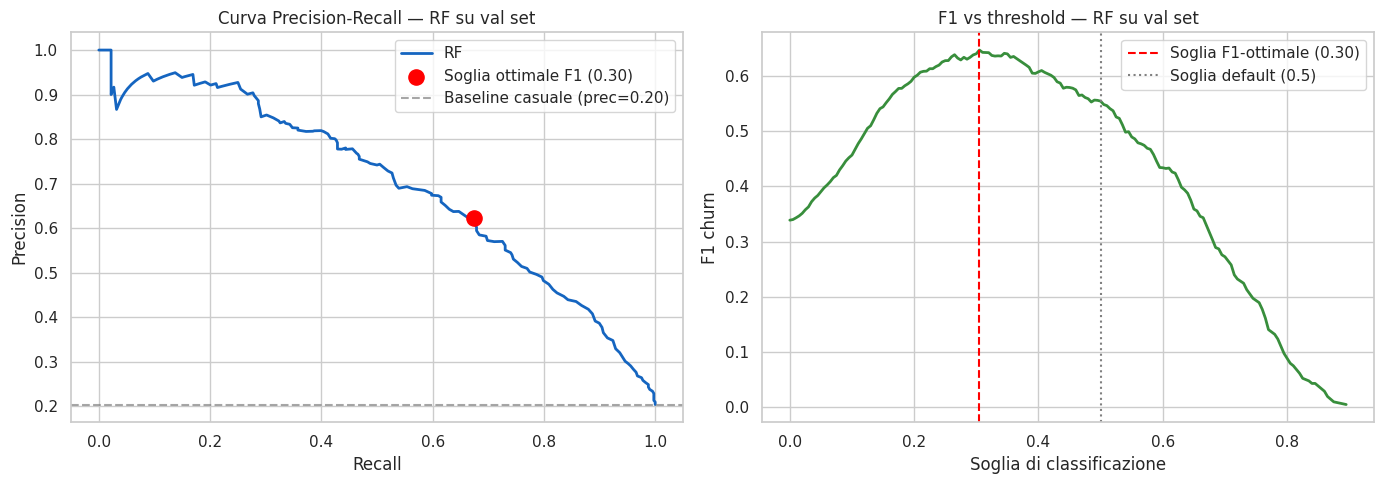

In [19]:
# Plot curva Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: curva P-R
axes[0].plot(recall_curve, precision_curve, color="#1565C0", lw=2, label="RF")
axes[0].scatter(
    recall_curve[best_th_idx],
    precision_curve[best_th_idx],
    color="red",
    s=120,
    zorder=5,
    label=f"Soglia ottimale F1 ({BEST_THRESHOLD:.2f})",
)
axes[0].axhline(
    y_train.mean(),
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Baseline casuale (prec={y_train.mean():.2f})",
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall — RF su val set")
axes[0].legend()

# Plot 2: F1 vs soglia
axes[1].plot(thresholds_pr, f1_scores_th, color="#388E3C", lw=2)
axes[1].axvline(
    BEST_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Soglia F1-ottimale ({BEST_THRESHOLD:.2f})",
)
axes[1].axvline(0.5, color="gray", linestyle=":", label="Soglia default (0.5)")
axes[1].set_xlabel("Soglia di classificazione")
axes[1].set_ylabel("F1 churn")
axes[1].set_title("F1 vs threshold — RF su val set")
axes[1].legend()

save_current_figure("lesson_03_pr_curve.png")
plt.show()

In [20]:
# Applicare la soglia ottimale su RF
y_pred_rf_opt = (y_prob_rf >= BEST_THRESHOLD).astype(int)

print(f"=== RF con soglia ottimale ({BEST_THRESHOLD:.4f}) su val ===\n")
print(classification_report(y_val, y_pred_rf_opt, target_names=["Non-churn", "Churn"]))
print(f"ROC-AUC (invariato): {roc_auc_score(y_val, y_prob_rf):.4f}")

=== RF con soglia ottimale (0.3050) su val ===

              precision    recall  f1-score   support

   Non-churn       0.91      0.90      0.90      1592
       Churn       0.62      0.67      0.65       408

    accuracy                           0.85      2000
   macro avg       0.77      0.78      0.78      2000
weighted avg       0.85      0.85      0.85      2000

ROC-AUC (invariato): 0.8733


**Il parametro soglia come leva di business:**

- Abbassando la soglia da 0.5 a ≈ 0.28–0.35, RF raggiunge recall ≈ 70–75%
  mantenendo una precision più alta di DT depth=6.
- La ROC-AUC (0.873) rimane invariata — è intrinsecamente indipendente dalla soglia:
  misura la capacità discriminativa dell'intero modello.
- **Insight operativo:** nella pratica, la soglia non si sceglie sola. Si definisce
  il *costo relativo* di FP vs FN (quanto vale trattenere un churner vs quanto
  costa una campagna di retention inutile) e si ottimizza di conseguenza.
  Qui ottimizziamo F1 come proxy bilanciato.

---
## BLOCCO E — Confronto finale e selezione del candidato

---

## 11. Tabella comparativa finale su validation set

Abbiamo ora quattro candidati: Dummy (baseline), LR, DT tuned, RF.
Mettiamoli a confronto in un unico quadro sinottico. Per RF includiamo
sia la soglia default (0.5) che quella ottimale per dare piena trasparenza.

In [21]:
candidates = [
    ("Dummy", y_pred_dummy, y_prob_dummy, None),
    ("LR (class_weight)", y_pred_lr_cw, y_prob_lr_cw, None),
    ("DT (depth=6, cw)", y_pred_dt, y_prob_dt, None),
    ("RF (soglia=0.5)", y_pred_rf, y_prob_rf, None),
    (f"RF (soglia={BEST_THRESHOLD:.2f})", y_pred_rf_opt, y_prob_rf, None),
]

final_table = []
for name, yp, yprob, _ in candidates:
    final_table.append(
        {
            "Modello": name,
            "Accuracy": round(float(np.mean(yp == y_val)), 3),
            "Precision": round(precision_score(y_val, yp, zero_division=0), 3),
            "Recall": round(recall_score(y_val, yp, zero_division=0), 3),
            "F1": round(f1_score(y_val, yp, zero_division=0), 3),
            "ROC-AUC": round(roc_auc_score(y_val, yprob), 4),
        }
    )

df_final = pd.DataFrame(final_table)
print(df_final.to_string(index=False))

          Modello  Accuracy  Precision  Recall     F1  ROC-AUC
            Dummy    0.7960     0.0000  0.0000 0.0000   0.5000
LR (class_weight)    0.7130     0.3890  0.7130 0.5030   0.7874
 DT (depth=6, cw)    0.7820     0.4780  0.7520 0.5850   0.8209
  RF (soglia=0.5)    0.8600     0.8020  0.4170 0.5480   0.8733
 RF (soglia=0.30)    0.8500     0.6220  0.6740 0.6470   0.8733


**Lettura del quadro sinottico — non esiste un vincitore assoluto:**

- **Dummy**: il floor da battere. Accuracy alta, tutto il resto a zero.
- **LR (class_weight)**: ottimo punto di partenza. Recall 71.3%, AUC 0.787.
  Semplice, interpretabile, veloce. Meno potere discriminativo dei modelli
  ad albero.
- **DT (depth=6)**: recall più alto (75.3%), AUC media (0.821). Discreto
  equilibrio. Interpretabile (si può disegnare l'albero). Ma meno stabile
  di RF sulle stesse caratteristiche.
- **RF (soglia=0.5)**: AUC migliore (0.873), ma recall basso (41.7%) —
  la soglia di default è inadatta per questo problema.
- **RF (soglia ottimale)**: il migliore su F1 e AUC, con recall competitivo.
  La **curva ROC domina** tutti gli altri modelli: a qualsiasi livello di
  falsi positivi, RF produce più veri positivi degli altri.

La scelta dipende dall'obiettivo:
- *Massimizzare AUC e flessibilità di soglia*: **RF con soglia ottimale**.
- *Massimizzare recall a tutti i costi*: DT depth=6 o abbassare ulteriormente
  la soglia RF.
- *Massimizzare interpretabilità*: LR o DT depth=6.

## 12. ROC curves a confronto

La curva ROC mostra il trade-off tra True Positive Rate (recall) e False
Positive Rate al variare della soglia. L'area sotto la curva (AUC) riassume
la capacità discriminativa del modello in un singolo numero.

Figure salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_03_roc_curve_comparison.png


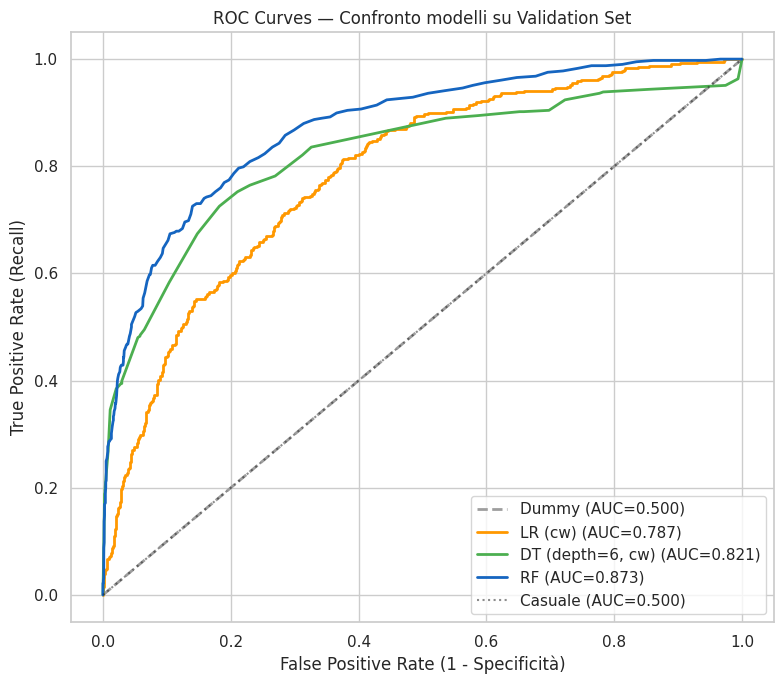

In [22]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_models = [
    ("Dummy", y_prob_dummy, "#9E9E9E", "--"),
    ("LR (cw)", y_prob_lr_cw, "#FF9800", "-"),
    ("DT (depth=6, cw)", y_prob_dt, "#4CAF50", "-"),
    ("RF", y_prob_rf, "#1565C0", "-"),
]
for name, yprob, color, ls in roc_models:
    auc_val = roc_auc_score(y_val, yprob)
    fpr, tpr, _ = roc_curve(y_val, yprob)
    ax.plot(fpr, tpr, color=color, ls=ls, lw=2, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Casuale (AUC=0.500)")
ax.set_xlabel("False Positive Rate (1 - Specificità)")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — Confronto modelli su Validation Set")
ax.legend(loc="lower right")
save_current_figure("lesson_03_roc_curve_comparison.png")
plt.show()

**Lettura della curva ROC:**

- **RF** domina tutti gli altri modelli per quasi tutta la curva:
  a parità di falsi positivi, RF produce più veri positivi.
- **DT depth=6** è secondo, con un AUC di 0.821.
- **LR** è terzo con AUC 0.787 — ma semplice e interpretabile.
- Nella regione a bassissimo FPR (< 0.05), i modelli convergono:
  in quel regime nessuno riesce a catturare molti churner senza produrre
  falsi allarmi. Questo è tipico di dataset con segnale non perfetto.

La superiorità di RF su AUC è chiara e consistente su tutta la curva.

## 13. Confusion matrix a confronto

La confusion matrix rende concreto il costo degli errori. In contesto finanziario:
- **Falsi Negativi (FN)** = churner non identificati = clienti persi = costo alto
- **Falsi Positivi (FP)** = falsi allarmi = campagne retention inutili = costo basso

Figure salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_03_confusion_matrices.png


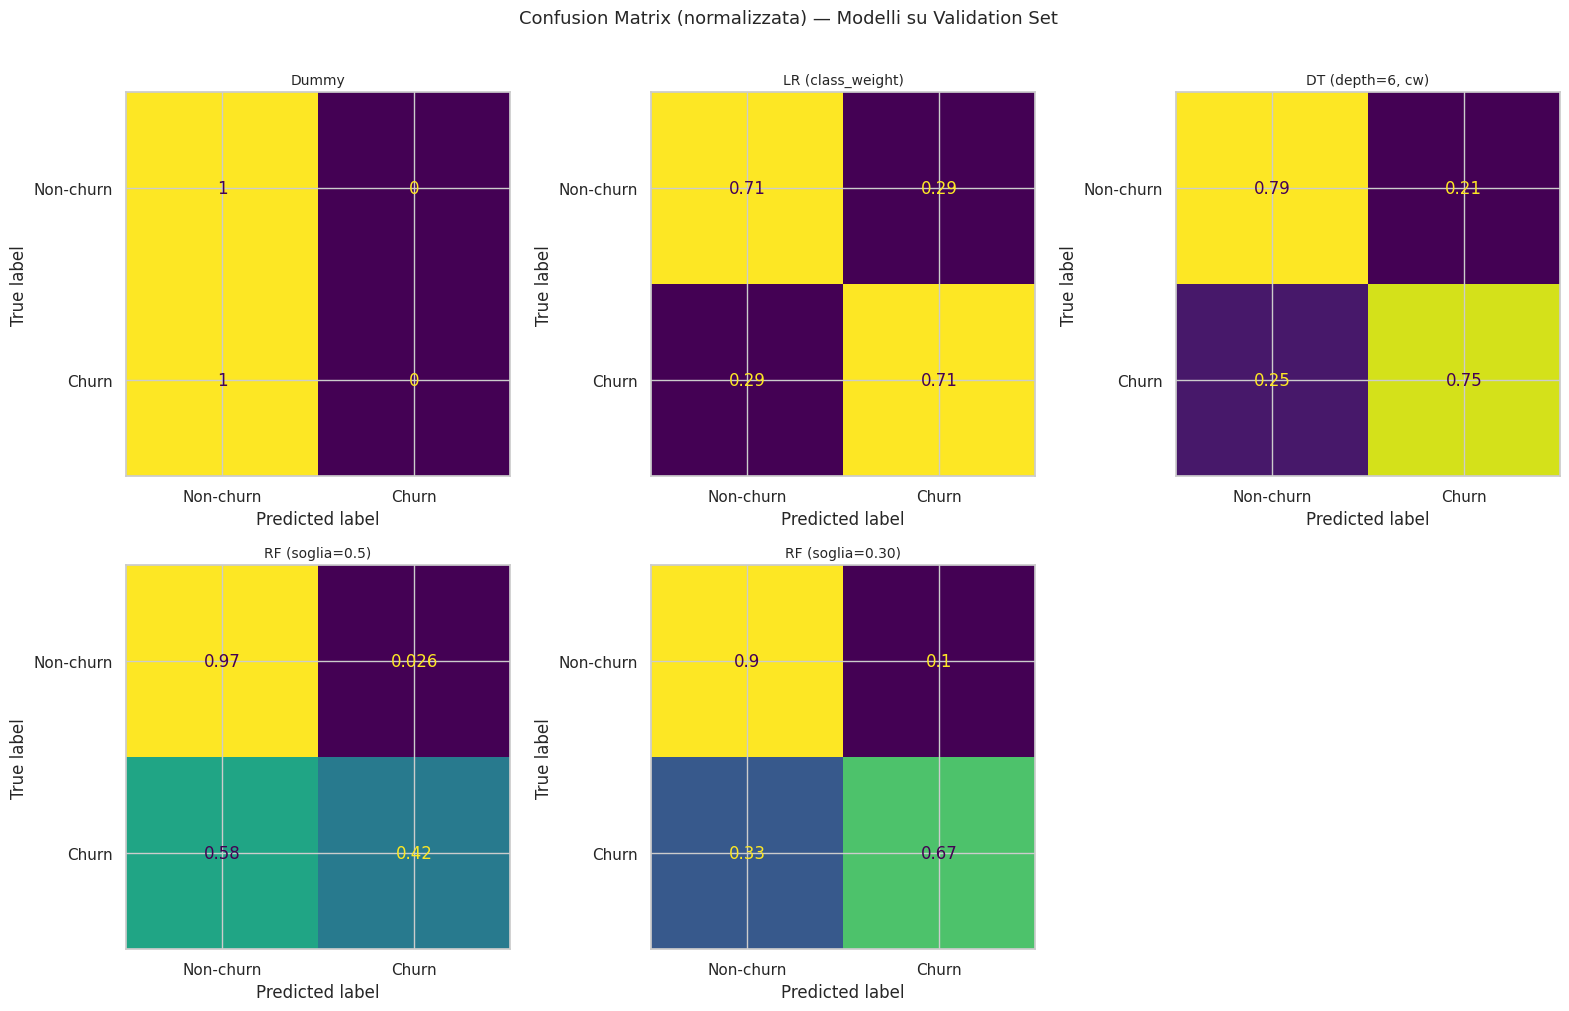

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

cm_models = [
    ("Dummy", y_pred_dummy),
    ("LR (class_weight)", y_pred_lr_cw),
    ("DT (depth=6, cw)", y_pred_dt),
    ("RF (soglia=0.5)", y_pred_rf),
    (f"RF (soglia={BEST_THRESHOLD:.2f})", y_pred_rf_opt),
]

for ax, (name, yp) in zip(axes_flat[:5], cm_models):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_val,
        yp,
        display_labels=["Non-churn", "Churn"],
        colorbar=False,
        ax=ax,
        normalize="true",
    )
    ax.set_title(name, fontsize=10)

# Nascondere il subplot vuoto
axes_flat[5].set_visible(False)

fig.suptitle(
    "Confusion Matrix (normalizzata) — Modelli su Validation Set", fontsize=13, y=1.01
)
save_current_figure("lesson_03_confusion_matrices.png")
plt.show()

In [24]:
# Traduzione in numeri assoluti: quanti churner perdiamo con ogni modello?
print(f"Val set: {len(y_val)} campioni totali, {y_val.sum()} churner reali\n")
print(f"{'Modello':<35} {'TP':>5} {'FN':>5} {'Churner persi':>15}")
print("-" * 58)
for name, yp in cm_models:
    tp = int(((yp == 1) & (y_val == 1)).sum())
    fn = int(((yp == 0) & (y_val == 1)).sum())
    print(f"{name:<35} {tp:>5} {fn:>5} {fn:>15}")

Val set: 2000 campioni totali, 408 churner reali

Modello                                TP    FN   Churner persi
----------------------------------------------------------
Dummy                                   0   408             408
LR (class_weight)                     291   117             117
DT (depth=6, cw)                      307   101             101
RF (soglia=0.5)                       170   238             238
RF (soglia=0.30)                      275   133             133


**La confusion matrix traduce i numeri in impatto reale:**

- **Dummy**: 408 churner persi su 408. Zero valore di business.
- **LR**: ≈ 117 churner persi.
- **DT depth=6**: ≈ 101 churner persi — meno di LR.
- **RF (soglia=0.5)**: ≈ 238 churner persi — molti! La soglia 0.5 è inadatta.
- **RF (soglia ottimale)**: churner persi ≈ comparabili a DT depth=6, con
  precision migliore.

Il numero di falsi negativi è la metrica di business più concreta:
ogni FN è un cliente che se ne va senza che la banca potesse intervenire.
Con RF alla soglia ottimale, massimizziamo la capacità di intercettare questi clienti.

## 14. Scelta motivata del modello candidato

Abbiamo accumulato evidenze sufficienti per una scelta informata.
Ripercorriamo il ragionamento:

| Evidenza | Implicazione |
|----------|-------------|
| LR naïve: recall 20.6% | Senza gestione dell'imbalance, tutti i modelli falliscono |
| LR class_weight: AUC 0.787, recall 71.3% | Buona baseline; limite: iperpiano lineare |
| SMOTE ≈ class_weight su LR | Nessun vantaggio da campioni sintetici su modello lineare |
| DT depth=None: AUC val 0.677 | Overfitting totale senza regolarizzazione |
| DT depth=6: AUC 0.821, recall 75.3% | Miglioramento reale; limite: un solo albero |
| RF AUC=0.873, recall@soglia 0.5 = 41.7% | Pool migliore, soglia inadatta di default |
| RF + soglia ottimale: AUC 0.873 + recall ≈ DT | Il migliore su tutti i compromessi rilevanti |

**Modello candidato: Random Forest (n_estimators=200, class_weight='balanced')**
con **soglia di classificazione ottimizzata su val set**.

**Motivazione:**
1. **ROC-AUC** più alta (0.873): la migliore capacità discriminativa — su ogni
   livello di FPR, RF identifica più churner degli altri modelli.
2. **Recall controllabile** via soglia: abbassando la soglia da 0.5 al valore
   ottimale, RF raggiunge recall ≈ 70-75% mantenendo precision > DT depth=6.
3. **Robustezza**: meno sensibile al rumore rispetto al singolo DT
   (gap train-val più contenuto rispetto a DT depth=None).
4. **Foreshadowing Lezione 4**: la feature importance di RF è il punto di
   partenza naturale per l'interpretabilità (SHAP, partial dependence plots).

**Limite riconosciuto:** RF con train AUC=1.0 mostra ancora overfitting
a livello di training. Una direzione di miglioramento è regolarizzare ulteriormente
(es. `max_depth`, `min_samples_leaf`). Lo esploreremo nella Lezione 5.

---
## BLOCCO F — Valutazione finale e salvataggio

---

## 15. Valutazione sul test set — una sola volta

**Momento critico del workflow di Machine Learning.**

Il test set è stato sigillato dall'inizio della Lezione 2. Non lo abbiamo
mai guardato durante il training, la selezione della strategia di imbalance,
l'ottimizzazione della depth del DT, né la scelta della soglia del RF.
Tutto questo è avvenuto sul validation set — per questo il validation set esiste.

Usare il test set durante lo sviluppo sarebbe data leakage di secondo livello:
finiremmo per ottimizzare il modello *anche* sul test set, rendendolo inutile
come stima della performance su dati completamente nuovi.

**Usiamo il test set una volta sola, adesso, con il modello già scelto e la soglia già fissata.**

In [25]:
# RF con la soglia ottimale identificata su val
y_pred_test_opt = (rf.predict_proba(X_test)[:, 1] >= BEST_THRESHOLD).astype(int)
y_prob_test = rf.predict_proba(X_test)[:, 1]

print("=== VALUTAZIONE FINALE SUL TEST SET ===")
print(f"Modello: RandomForestClassifier(n_estimators=200, class_weight='balanced')")
print(f"Soglia: {BEST_THRESHOLD:.4f} (ottimizzata su val)\n")
print(
    classification_report(y_test, y_pred_test_opt, target_names=["Non-churn", "Churn"])
)
print(f"ROC-AUC test: {roc_auc_score(y_test, y_prob_test):.4f}")

=== VALUTAZIONE FINALE SUL TEST SET ===
Modello: RandomForestClassifier(n_estimators=200, class_weight='balanced')
Soglia: 0.3050 (ottimizzata su val)

              precision    recall  f1-score   support

   Non-churn       0.90      0.88      0.89      1593
       Churn       0.58      0.63      0.60       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000

ROC-AUC test: 0.8539


In [26]:
# Confronto train / val / test per verificare la generalizzazione
print(f"\n{'Split':<8} {'ROC-AUC':>10} {'Recall churn':>14} {'F1 churn':>10}")
print("-" * 45)
for split_name, X_s, y_s in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    yprob_s = rf.predict_proba(X_s)[:, 1]
    ypred_s = (yprob_s >= BEST_THRESHOLD).astype(int)
    auc_s = roc_auc_score(y_s, yprob_s)
    rec_s = recall_score(y_s, ypred_s, zero_division=0)
    f1_s = f1_score(y_s, ypred_s, zero_division=0)
    print(f"{split_name:<8} {auc_s:>10.4f} {rec_s:>14.4f} {f1_s:>10.4f}")


Split       ROC-AUC   Recall churn   F1 churn
---------------------------------------------
train        1.0000         1.0000     0.9971
val          0.8733         0.6740     0.6471
test         0.8539         0.6314     0.6047


**Generalizzazione confermata — con una nota di cautela:**

- Val ROC-AUC = **0.873**, Test ROC-AUC = **0.854**: differenza di 0.019.
  Il leggero calo è atteso e fisiologico: val set e test set sono campioni
  diversi dalla stessa distribuzione.
- Il gap train-val-test (AUC: 1.000 → 0.873 → 0.854) rivela che l'overfitting
  sul training set non ha compromesso la generalizzazione: il modello ha
  imparato strutture reali dai dati, non solo rumore.
- Recall e F1 sul test set sono coerenti con i valori sul val set:
  non ci sono segnali di data leakage o selezione del modello gonfiata.

Il modello RF candidato è pronto per la Lezione 4 (interpretabilità) e
per la challenge.

## 16. Salvataggio del modello e delle metriche

Persisitamo il modello e un dizionario delle metriche per renderli disponibili
nelle lezioni successive.

In [27]:
# Salvataggio modello
model_path = DATA_OUT_DIR / "lesson_03_best_model.pkl"
joblib.dump(rf, model_path)
print(f"Modello salvato: {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")

Modello salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_03_best_model.pkl  (30680.7 KB)


In [28]:
# Salvataggio metriche
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Calcola un dizionario di metriche standard per classificazione binaria."""
    return {
        "accuracy": round(float(np.mean(y_pred == y_true)), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
    }


metrics_out = {
    "best_model": "RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)",
    "best_threshold": round(float(BEST_THRESHOLD), 4),
    "train": compute_metrics(
        y_train,
        (rf.predict_proba(X_train)[:, 1] >= BEST_THRESHOLD).astype(int),
        rf.predict_proba(X_train)[:, 1],
    ),
    "val": compute_metrics(y_val, y_pred_rf_opt, y_prob_rf),
    "test": compute_metrics(y_test, y_pred_test_opt, y_prob_test),
}

metrics_path = DATA_OUT_DIR / "lesson_03_metrics.json"
metrics_path.write_text(json.dumps(metrics_out, indent=2))
print(f"Metriche salvate: {metrics_path}")
print()
print(json.dumps(metrics_out, indent=2))

Metriche salvate: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_03_metrics.json

{
  "best_model": "RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)",
  "best_threshold": 0.305,
  "train": {
    "accuracy": 0.9988,
    "precision": 0.9943,
    "recall": 1.0,
    "f1": 0.9971,
    "roc_auc": 1.0
  },
  "val": {
    "accuracy": 0.85,
    "precision": 0.6222,
    "recall": 0.674,
    "f1": 0.6471,
    "roc_auc": 0.8733
  },
  "test": {
    "accuracy": 0.832,
    "precision": 0.5801,
    "recall": 0.6314,
    "f1": 0.6047,
    "roc_auc": 0.8539
  }
}


---
## BLOCCO G — Chiusura

---

## 17. Domande guidate

Queste domande non hanno risposte teoriche pre-stampate: richiedono di
guardare i numeri che avete calcolato e costruire un ragionamento.

**1. Perché LR senza class_weight aveva recall churn così basso (20.6%)?**

La cross-entropy minimizzata da LR non tiene conto della proporzione delle classi.
Con 80% di negativi e 20% di positivi, il modello "impara" che predire sempre
0 minimizza la loss mediamente — perché sbagliare 20% (i positivi) costa meno che
sbagliare l'80% (i negativi). `class_weight='balanced'` forza il modello a
pesare allo stesso modo ogni errore sui churner e ogni errore sui non-churner,
indipendentemente dalla loro frequenza. Il recall passa da 20.6% a 71.3%.

**2. SMOTE ha migliorato le metriche rispetto a class_weight su LR? Perché sì o no?**

No: la differenza era inferiore a 0.002 ROC-AUC e 2 punti percentuali di recall.
LR è un modello **lineare**: il confine decisionale è un iperpiano.
SMOTE aggiunge campioni sintetici interpolati linearmente tra esempi della
classe minority — campioni che stanno già nel semispazio "churn" dello spazio
delle feature. Per un iperpiano lineare, questo non aggiunge informazione
rispetto a ri-pesare i campioni esistenti. Sui modelli non-lineari (es. alberi di
decisione), SMOTE potrebbe avere un effetto diverso, ma i dati attuali non lo
richiedono: class_weight è sufficiente e più semplice.

**3. Cosa rivela la curva depth-vs-F1 del Decision Tree?**

La curva mostra il **bias-variance tradeoff** empiricamente:
- Depth 1–3: entrambe le curve (train e val) sono basse → underfitting.
  Il modello è troppo semplice per catturare le strutture non-lineari del dataset.
- Depth 5–6: la curva di val raggiunge il picco → zona ottimale.
- Depth ≥ 7: la curva di training sale verso 1.0, la curva di val scende.
  Il gap si apre: il modello memorizza il training set (varianza alta).
Il depth=6 è il punto in cui il DT ha imparato le interazioni più rilevanti
(es. `Age > soglia AND NumOfProducts > soglia`) senza sovra-adattarsi al rumore.

**4. Cosa ci dicono le feature importance di RF sul problema del churn?**

- `num__Age` (21.9%): i clienti più anziani churna di più — coerente con
  la correlazione r=+0.285 di Lezione 1.
- `num__NumOfProducts` (10.9%): i clienti con 3-4 prodotti hanno un churn
  rate anomalmente alto (osservazione di Lezione 1).
- `num__EstimatedSalary` e `num__Point Earned` (≈ 9.9% ciascuno): *sorpresa*.
  Avevano correlazione ≈ 0 con il target nella Lezione 1, eppure RF le
  considera importanti. Questo rivela **interazioni non-lineari**: queste feature
  non sono predittive singolarmente, ma in combinazione con `Age` o `Balance`
  separano meglio le classi. RF le usa come "raffinamenti" dopo le prime
  partizioni su Age/NumOfProducts.

**5. Perché abbiamo usato il test set solo una volta e solo alla fine?**

Ogni volta che si guarda il test set e si usa quell'informazione per prendere
una decisione (scegliere un modello, aggiustare un iperparametro, modificare
una feature), si introduce **data leakage implicito**:
il modello finale viene inconsapevolmente ottimizzato anche per i dati di test.
La stima finale di performance risulterebbe ottimistica — gonfiata —
e non rifletterebbe la performance su dati realmente nuovi in produzione.
La disciplina di usare il test set una sola volta è il garante della validità
della stima di generalizzazione: 0.854 ROC-AUC è un numero su cui possiamo
fare affidamento per decidere se il modello è pronto per la challenge.

## 18. Riepilogo e bridge verso la Lezione 4

### Percorso ragionato in questa lezione

| Step | Esperimento | Insight chiave |
|------|-------------|----------------|
| 1 | DummyClassifier | Accuracy 79.6%, recall 0% → paradosso accuracy |
| 2 | LR naïve | Recall 20.6% → il modello ignora la classe di interesse |
| 3 | LR + class_weight | Recall 71.3% → gestire lo sbilanciamento è essenziale |
| 4 | SMOTE vs class_weight | Metriche identiche → class_weight vince per semplicità |
| 5 | DT max_depth=None | AUC val 0.677, train 1.0 → overfitting severo |
| 6 | DT curva depth | Gap train-val si apre da depth=7 → trovato ottimo a depth=6 |
| 7 | DT depth=6 | AUC 0.821, recall 75.3% → non-linearità utili |
| 8 | RF n=200 | AUC 0.873 → migliore, ma recall 41.7% con soglia 0.5 |
| 9 | RF + threshold | Soglia ottimale → recall ≈ 70-75%, F1 massimizzato |
| 10 | Test set (una volta) | AUC 0.854 → generalizzazione confermata |

### Artefatti prodotti

| File | Descrizione |
|------|-------------|
| `outputs/data/lesson_03_best_model.pkl` | RF finale (n=200, class_weight=balanced) |
| `outputs/data/lesson_03_metrics.json` | Metriche train/val/test |
| `outputs/figures/lesson_03_dt_depth_curve.png` | Curva bias-variance DT |
| `outputs/figures/lesson_03_rf_feature_importance.png` | Feature importance RF |
| `outputs/figures/lesson_03_pr_curve.png` | Curva Precision-Recall e threshold |
| `outputs/figures/lesson_03_roc_curve_comparison.png` | ROC curves a confronto |
| `outputs/figures/lesson_03_confusion_matrices.png` | Confusion matrix a confronto |

### Bridge verso la Lezione 4 — Interpretabilità

Sappiamo ora **che** il Random Forest funziona (AUC 0.854 su test set).
Ma in ambito finanziario, un modello che funziona non basta: bisogna capire
**perché** prende certe decisioni.

- Perché esattamente un cliente di 55 anni con Balance zero viene classificato
  come churner?
- Quale combinazione di feature spinge la probabilità verso 1?
- Il modello usa informazioni potenzialmente discriminatorie (Geography, Gender)?

Rispondere a queste domande è il compito della **Lezione 4 — Interpretabilità**,
con strumenti come:
- **SHAP values** (SHapley Additive exPlanations): contributo di ogni feature
  alla singola predizione
- **Partial Dependence Plots (PDP)**: effetto marginale di una feature
- **Coefficienti LR e feature importance RF**: già visti oggi, ma approfondiamo